# Project Understanding
**Source Data**:
The dataset used is data from https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset
<br> This project aims to analyze customer subscription habits and predict churn.

#### Data Dictionary :
- CustomerID: A unique ID that identifies each customer.
- Count: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.
- Country: The country of the customer’s primary residence.
- State: The state of the customer’s primary residence.
- City: The city of the customer’s primary residence.
- Zip Code: The zip code of the customer’s primary residence.
- Lat Long: The combined latitude and longitude of the customer’s primary residence.
- Latitude: The latitude of the customer’s primary residence.
- Longitude: The longitude of the customer’s primary residence.
- Gender: The customer’s gender: Male, Female
- Senior Citizen: Indicates if the customer is 65 or older: Yes, No
- Partner: Indicate if the customer has a partner: Yes, No
- Dependents: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.
- Tenure Months: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.
- Phone Service: Indicates if the customer subscribes to home phone service with the company: Yes, No
- Multiple Lines: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No
- Internet Service: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.
- Online Security: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No
- Online Backup: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No
- Device Protection: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No
- Tech Support: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No
- Streaming TV: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.
- Streaming Movies: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.
- Contract: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.
- Paperless Billing: Indicates if the customer has chosen paperless billing: Yes, No
- Payment Method: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check
- Monthly Charge: Indicates the customer’s current total monthly charge for all their services from the company.
- Total Charges: Indicates the customer’s total charges, calculated to the end of the quarter specified above.
- Churn Label: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.
- Churn Value: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.
- Churn Score: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.
- CLTV: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.
- Churn Reason: A customer’s specific reason for leaving the company. Directly related to Churn Category.

# Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, kruskal, chi2_contingency
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.svm import SVC
from imblearn.combine import SMOTETomek

from skopt import BayesSearchCV
import random

import warnings
warnings.filterwarnings("ignore")

# Load Data

In [7]:
df = pd.read_excel('Telco_customer_churn.xlsx')

In [8]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

# Data Pre-Processing

In [10]:
df = df.drop(columns=['Count', 'Country', 'State', 'Churn Score', 'Churn Value', 'Churn Reason', 'Lat Long'])

In [11]:
df['Total Charges'].head()

0     108.15
1     151.65
2      820.5
3    3046.05
4     5036.3
Name: Total Charges, dtype: object

In [12]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors="coerce")

In [13]:
df.isna().sum()

CustomerID            0
City                  0
Zip Code              0
Latitude              0
Longitude             0
Gender                0
Senior Citizen        0
Partner               0
Dependents            0
Tenure Months         0
Phone Service         0
Multiple Lines        0
Internet Service      0
Online Security       0
Online Backup         0
Device Protection     0
Tech Support          0
Streaming TV          0
Streaming Movies      0
Contract              0
Paperless Billing     0
Payment Method        0
Monthly Charges       0
Total Charges        11
Churn Label           0
CLTV                  0
dtype: int64

In [14]:
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

In [15]:
df.isna().sum()

CustomerID           0
City                 0
Zip Code             0
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
CLTV                 0
dtype: int64

In [16]:
payment_methods = []
for i in df['Payment Method']:
    if i == 'Electronic check':
        payment_methods.append('EC')
    elif i == 'Mailed check':
        payment_methods.append('MC')
    elif i == 'Bank transfer (automatic)':
        payment_methods.append('BT')
    elif i == 'Credit card (automatic)':
        payment_methods.append('CC')
    else:
        payment_methods.append('Unknown')

In [17]:
df['Payment Method'] = payment_methods

# EDA

In [18]:
df.select_dtypes(include='object').drop(columns=['City']).head()

,CustomerID,Gender,Senior Citizen,Partner,Dependents,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Churn Label
0,3668-QPYBK,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,MC,Yes
1,9237-HQITU,Female,No,No,Yes,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,EC,Yes
2,9305-CDSKC,Female,No,No,Yes,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,EC,Yes
3,7892-POOKP,Female,No,Yes,Yes,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,EC,Yes
4,0280-XJGEX,Male,No,No,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,BT,Yes


In [19]:
df.select_dtypes(exclude='object').drop(columns=['Zip Code', 'Latitude', 'Longitude']).head()

,Tenure Months,Monthly Charges,Total Charges,CLTV
0,2,53.85,108.15,3239
1,2,70.70,151.65,2701
2,8,99.65,820.50,5372
3,28,104.80,3046.05,5003
4,49,103.70,5036.30,5340


In [20]:
df_num = df.select_dtypes(exclude='object').drop(columns=['Zip Code', 'Latitude', 'Longitude'])
df_cat = df.select_dtypes(include='object').drop(columns=['City', 'CustomerID'])
df_geo = df[['Zip Code', 'Latitude', 'Longitude', 'City', 'CustomerID']]

## Label Distribution

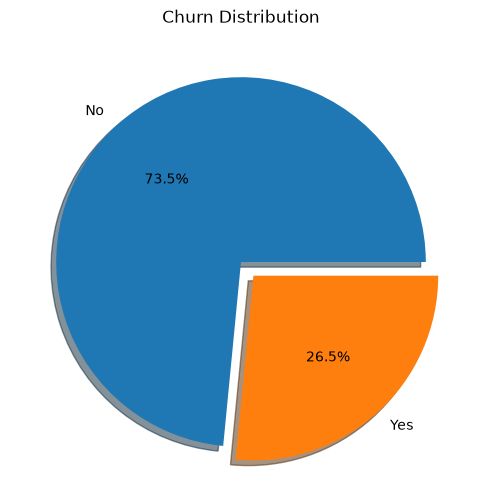

In [21]:
df_cat['Churn Label'].value_counts().plot.pie(
    autopct='%1.1f%%',
    explode=(0, 0.1),
    figsize=(6, 6),    
    shadow=True,
    title='Churn Distribution' 
)
plt.show()

Based on the plot above it shows that 26.5% customers are churn and 73.5% are not churn.

## Numerical Features Analysis

In [22]:
df_num.head()

,Tenure Months,Monthly Charges,Total Charges,CLTV
0,2,53.85,108.15,3239
1,2,70.70,151.65,2701
2,8,99.65,820.50,5372
3,28,104.80,3046.05,5003
4,49,103.70,5036.30,5340


In [23]:
def histplot_and_boxplot(df_num, column, hue):
    
    fig, axes = plt.subplots(1,4, figsize=(20, 4))
    palette={
        "Yes": "#ff7f0e",
        "No": "#1f77b4"
    }
    sns.histplot(data=df_num, x=column, ax=axes[0])
    axes[0].set_title(f'{column} Distribution')
    q1 = df_num[column].quantile(0.25)
    q3 = df_num[column].quantile(0.75)
    axes[0].axvline(q1, color='red', linestyle='--')
    axes[0].axvline(q3, color='blue', linestyle='--')
    ymax= axes[0].get_ylim()[1]
    xmax = axes[0].get_xlim()[1]
    axes[0].text(x=q1-(q1*0.05), y=ymax-ymax*0.1, s='Q1', color='red', 
                 va='bottom', ha='right', fontsize=9)
    axes[0].text(x=q3+(q3*0.05), y=ymax-ymax*0.1, s='Q3', color='blue', 
                 va='bottom', ha='left', fontsize=9)
    axes[0].text(x=xmax-xmax*0.35, y=ymax*0.5, s=f'Q1 & Q3\nQ1 = {q1}\nQ3 = {q3}', color='red', 
                 va='bottom', ha='left', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='red', boxstyle='round,pad=0.3'))    
    
    sns.histplot(data=df_num, x=column, hue=hue, multiple="stack", stat="count", discrete=False, ax=axes[1], palette=palette)
    axes[1].set_title(f'{column} Distribution')
    q1_churn_yes = df_num[df_num[hue] == 'Yes'][column].quantile(0.25)
    q3_churn_yes = df_num[df_num[hue] == 'Yes'][column].quantile(0.75)
    axes[1].axvline(q1_churn_yes, color='purple', linestyle='--')
    axes[1].axvline(q3_churn_yes, color='blue', linestyle='--')
    ymax_churn_yes= axes[1].get_ylim()[1]
    xmax_churn_yes = axes[1].get_xlim()[1]
    axes[1].text(x=q1_churn_yes-(q1_churn_yes*0.05), y=ymax_churn_yes-ymax_churn_yes*0.1, s='Q1', color='purple', 
                 va='bottom', ha='right', fontsize=9)
    axes[1].text(x=q3_churn_yes+(q3_churn_yes*0.05), y=ymax_churn_yes-ymax_churn_yes*0.1, s='Q3', color='blue', 
                 va='bottom', ha='left', fontsize=9)
    axes[1].text(x=xmax_churn_yes-xmax_churn_yes*0.35, y=ymax_churn_yes*0.5, s=f'Q1 & Q3 Churn = yes\nQ1 = {q1_churn_yes}\nQ3 = {q3_churn_yes}', color='red', 
                 va='bottom', ha='left', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='red', boxstyle='round,pad=0.3'))

    sns.boxplot(data=df_num, y=column, width=0.4, ax=axes[2])
    axes[2].set_title(f'{column} Distribution')
    axes[2].axhline(q1, color='red', linestyle='--', label='Q1')
    axes[2].axhline(q3, color='blue', linestyle='--', label='Q3')
    axes[2].text(x=-0.4, y=q1-q1*0.1, s=f'Q1 = {q1:.2f}', color='red', 
                 va='top', ha='left', fontsize=9)
    axes[2].text(x=-0.4, y=q3+q3*0.1, s=f'Q3 = {q3:.2f}', color='blue', 
                 va='bottom', ha='left', fontsize=9)
    axes[2].legend()
    
    sns.boxplot(data=df_num, y=column, hue=hue, gap=0.2, width=0.6, ax=axes[3], palette=palette)
    axes[3].set_title(f'{column} Distribution')

    plt.tight_layout()
    plt.show()

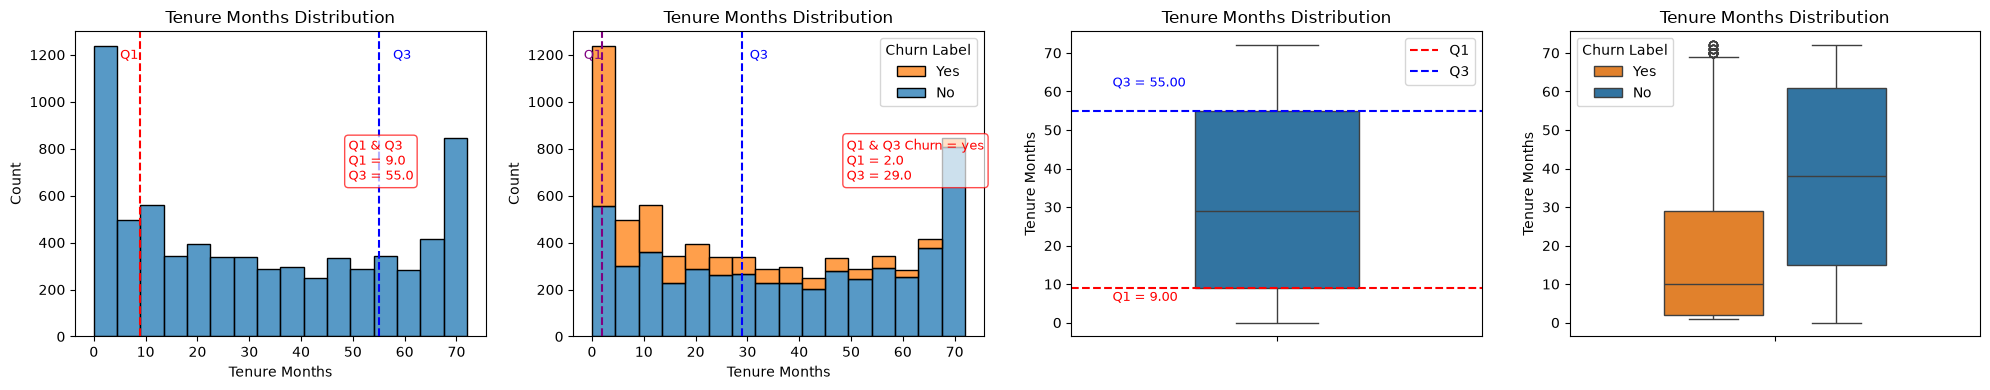

In [24]:
histplot_and_boxplot(df, 'Tenure Months', 'Churn Label')

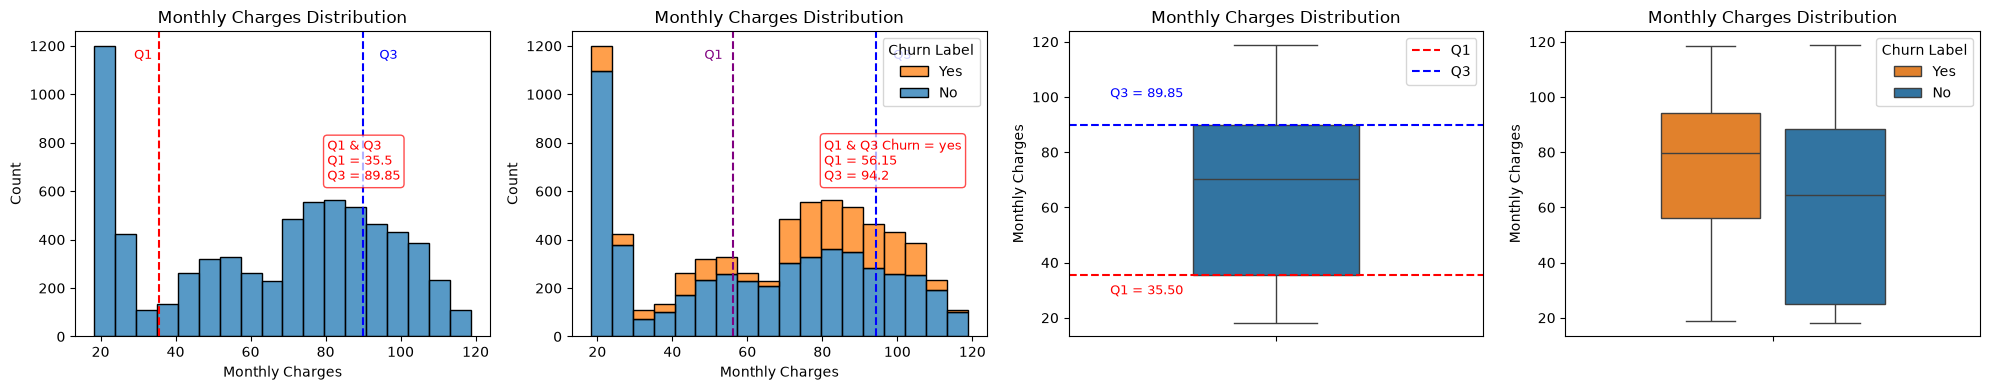

In [25]:
histplot_and_boxplot(df, 'Monthly Charges', 'Churn Label')

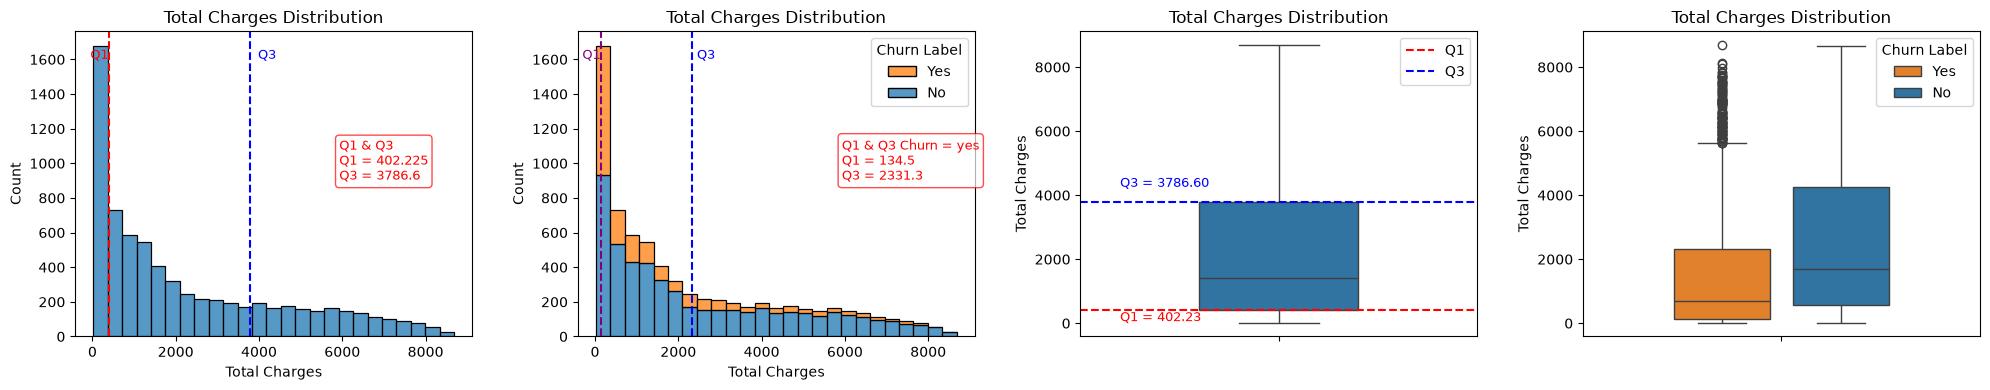

In [26]:
histplot_and_boxplot(df, 'Total Charges', 'Churn Label')

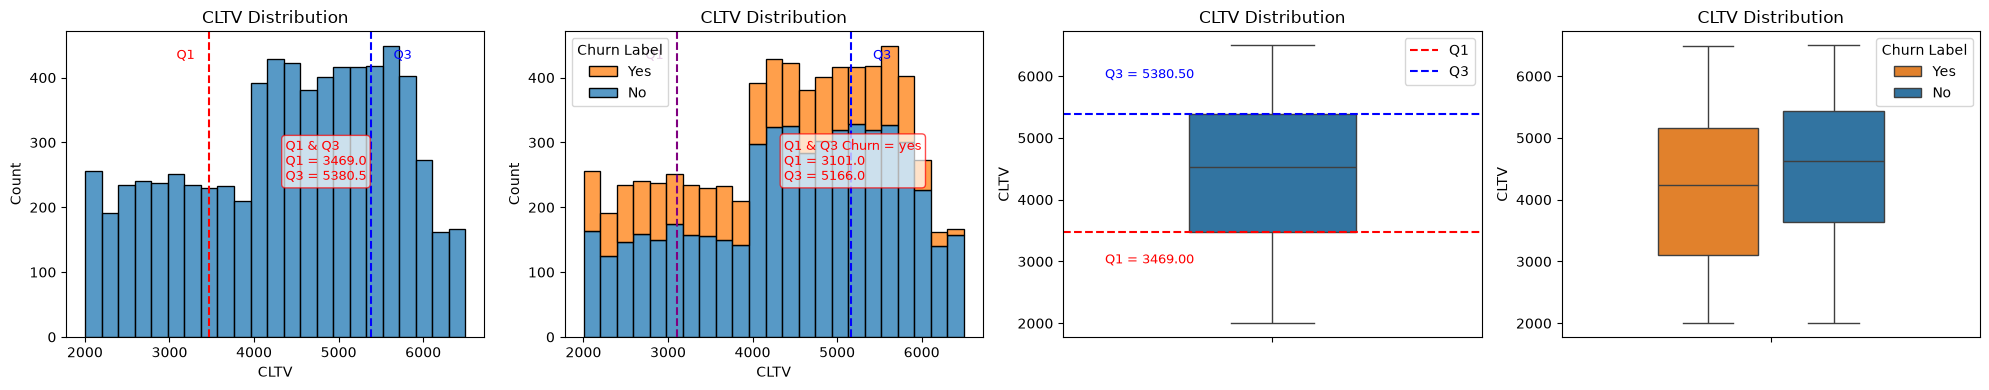

In [27]:
histplot_and_boxplot(df, 'CLTV', 'Churn Label')

- Tenure(how long has been subscribe), The majority tenure of customers are in range 9-55 months, and tenure customers who churn are in range 2-29 months.
- MonthlyCharges, The majority monthly charges of customers are in range 35.59-89.86, and monthly charges customers who churn are in range 56.15-94.2.
- TotalCharges, The majority total charges of customers are in range 401-3749, and total charges customers who churn are in range 134-2331.
- All numerical features are not in normal distribution shape, so for correlation analysis and feature scalling we will use spearman and robustscaler.

# Categorical Features Analysis

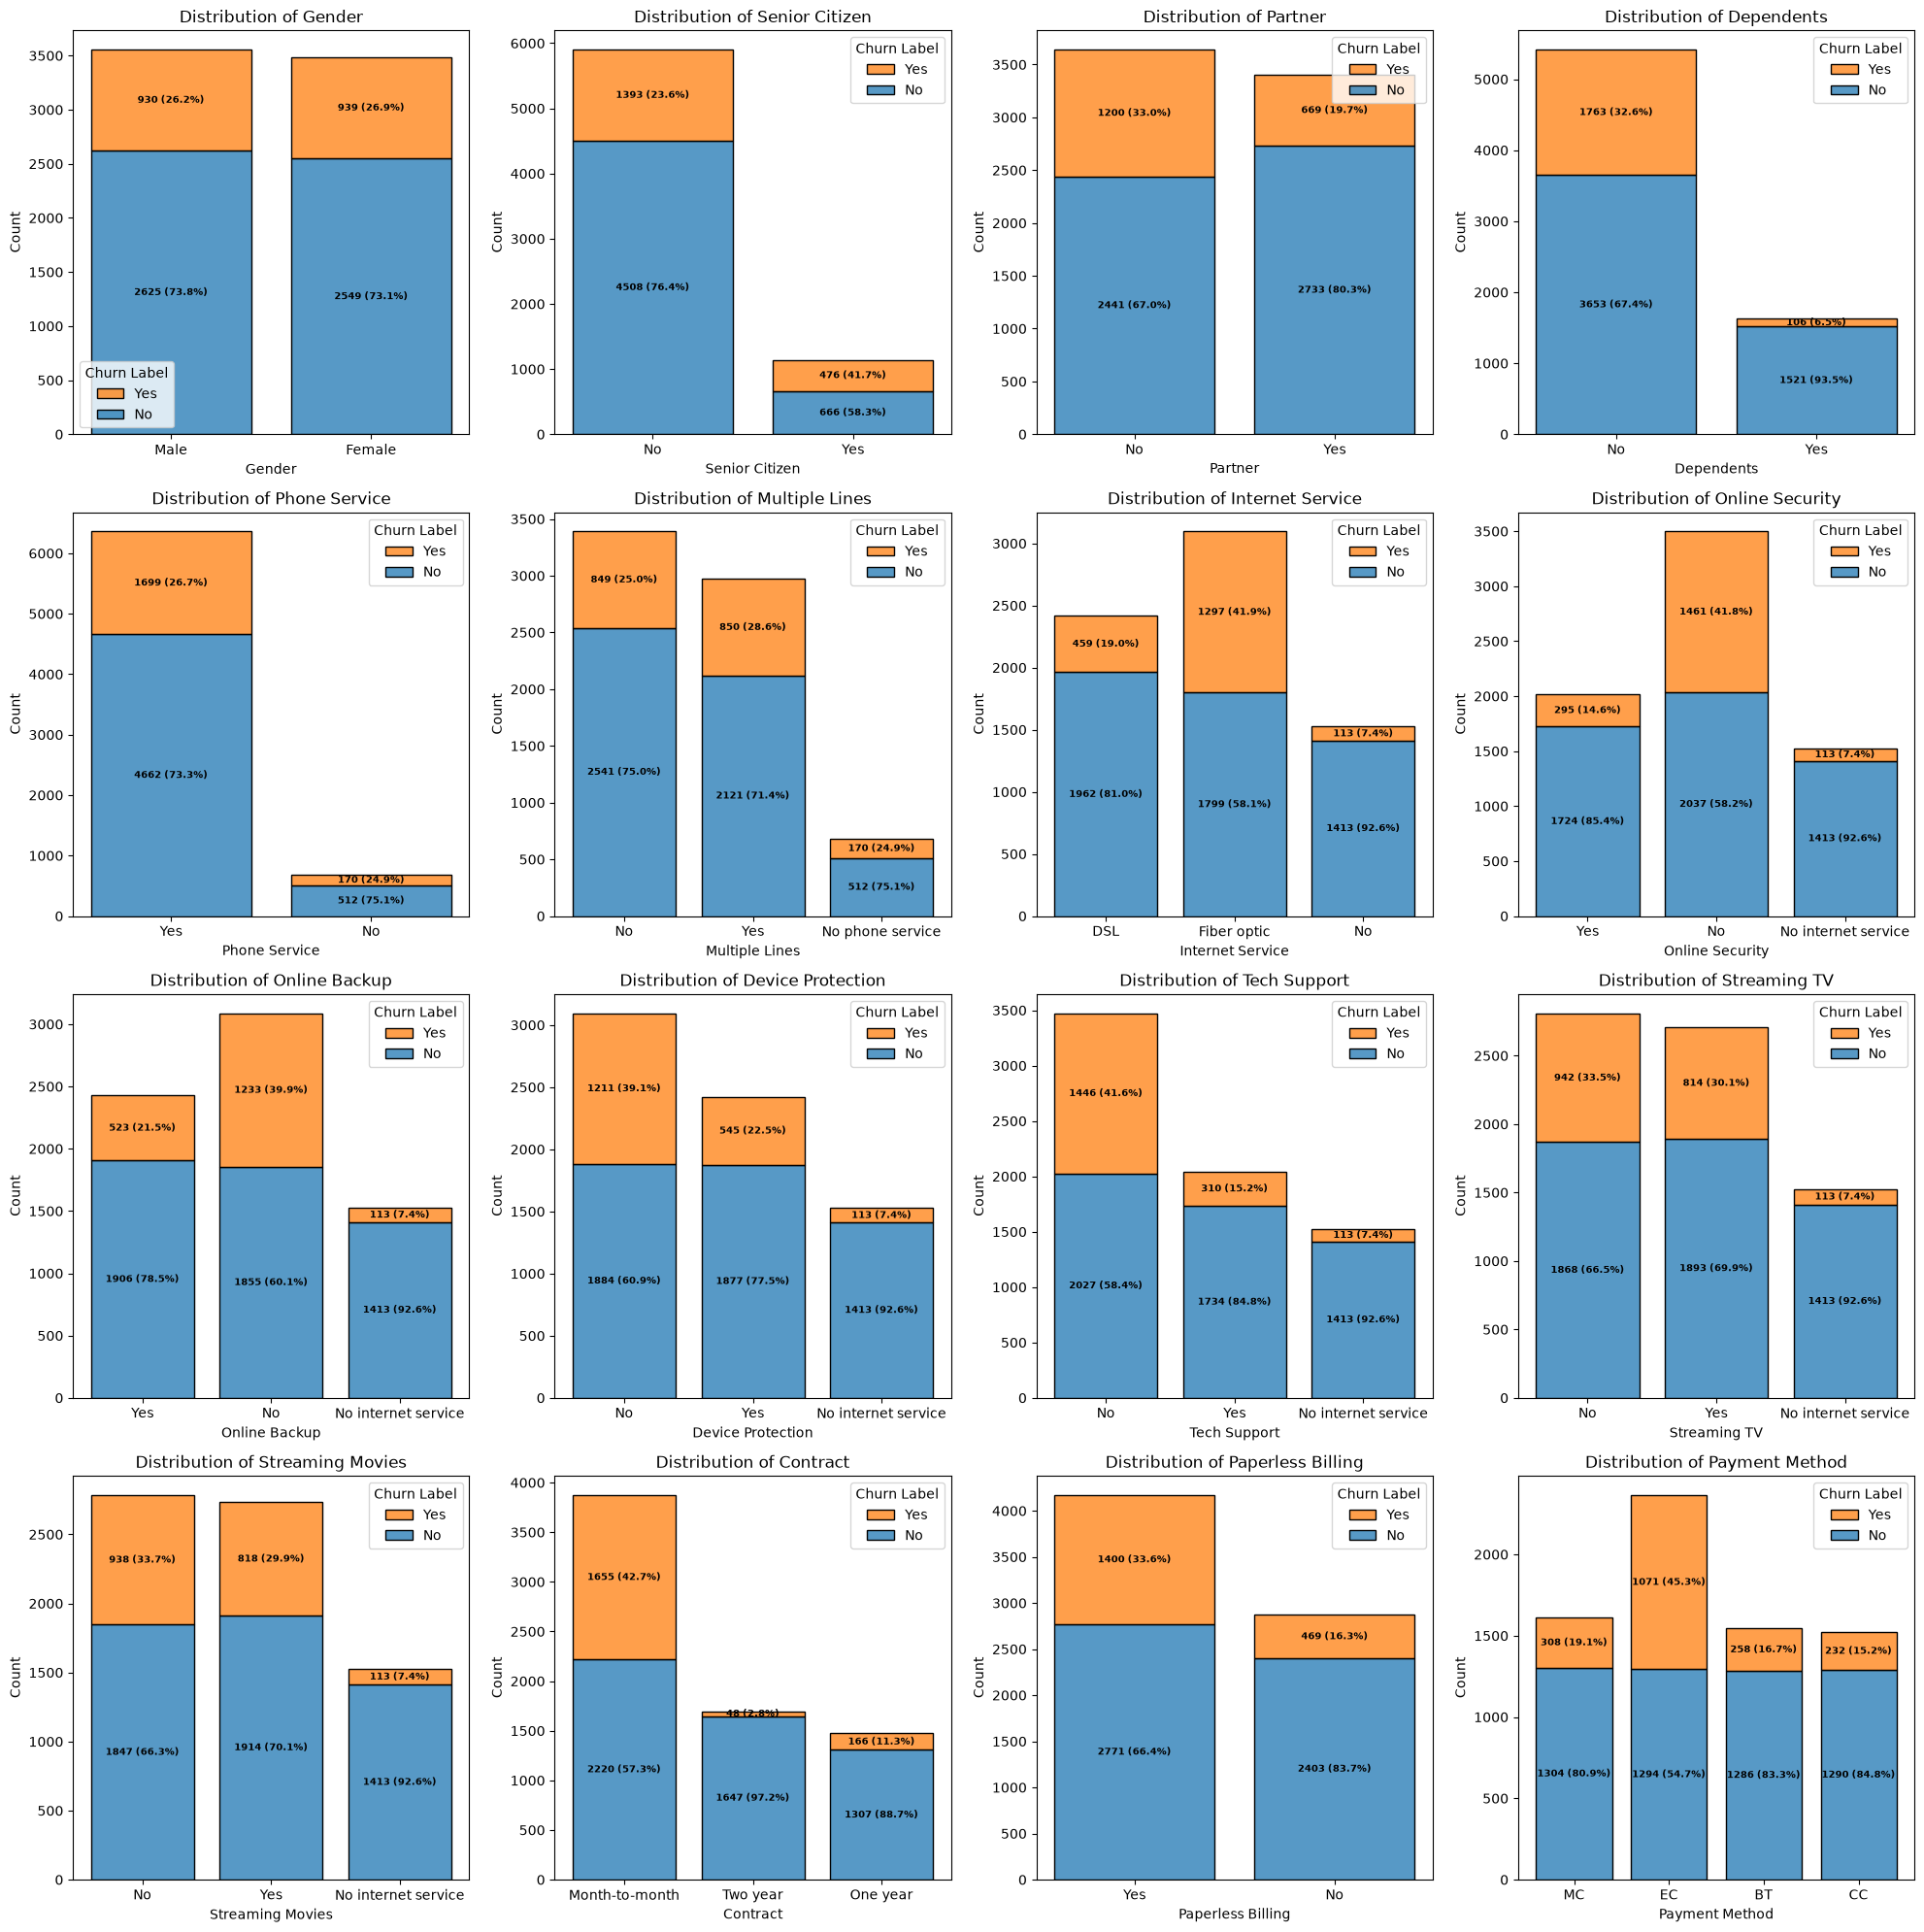

In [28]:
row = 0
col = 0
column_names = df_cat.drop(columns=['Churn Label']).columns
index_column = 0
palette={
    "Yes": "#ff7f0e",
    "No": "#1f77b4"
}

def set_number_in_stacked_bar(ax):
    totals = {}
    for p in ax.patches:
        x_pos = p.get_x()
        totals[x_pos] = totals.get(x_pos, 0) + p.get_height()
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # hanya tampilkan kalau ada nilai
            x_pos = p.get_x() + p.get_width()/2
            y_pos = p.get_y() + height/2
            
            total = totals[p.get_x()]
            percent = height / total * 100
            
            ax.text(
                x_pos, y_pos,
                f"{int(height)} ({percent:.1f}%)",  # tampilkan nilai + persentase
                ha="center", va="center", color="black", fontweight="bold", fontsize=7
            )
        
fig, axes= plt.subplots(4, 4, figsize=(20, 20))
for row in range(0, 4):
    for col in range(0, 4):
        if index_column < 16:
            if col < 4:
                sns.histplot(data=df_cat, x=column_names[index_column], hue="Churn Label", multiple="stack", stat="count", discrete=True, shrink=.8, ax=axes[row][col], palette=palette)
                axes[row][col].set_title(f'Distribution of {column_names[index_column]}')
                set_number_in_stacked_bar(axes[row][col])
                col+=1
                index_column+=1
            else:
                col=0
                sns.histplot(data=df_cat, x=column_names[index_column], hue="Churn Label", multiple="stack", stat="count", discrete=True, shrink=.8, ax=axes[row][col], palette=palette)
                axes[row][col].set_title(f'Distribution of {column_names[index_column]}')
                set_number_in_stacked_bar(axes[row][col])
                col+=1
                index_column+=1
        else:
            break
    row+=1

plt.tight_layout()
plt.show()

1. Gender:
- Analysis: Gender has almost no impact on churn.
- Data: Females churn at 27.0% and Males at 26.2%. This is a neutral factor.

2. Distribution of SeniorCitizen:
- Analysis: Being a senior citizen is a significant risk factor.
- Data: Seniors churn at a much higher rate (41.7%) compared to non-seniors (23.7%).

3. Distribution of Partner:
- Analysis: Customers without a partner are more unstable.
- Data: Those without a partner have a 33.0% churn rate, while those with a partner drop to 19.7%.

4. Distribution of Dependents:
- Analysis: Having dependents is a strong retention factor.
- Data: Customers with no dependents churn at 31.3%, whereas those with dependents have a low churn rate of 15.5%.

5. Distribution of PhoneService:
- Analysis: Having phone service slightly increases the likelihood of churn, but the difference is small.
- Data: "Yes" churns at 26.7% vs. "No" at 25.0%.

6. Distribution of MultipleLines:
- Analysis: Customers with multiple lines churn slightly more often, likely due to higher bills.
- Data: "Yes" (multiple lines) churns at 28.6%, while single lines ("No") churn at 25.1%.

7. Distribution of InternetService:
- Analysis: This is a critical pain point. Fiber Optic users are extremely unhappy or finding better value elsewhere.
- Data: Fiber optic users have a massive 41.9% churn rate, compared to just 19.0% for DSL users.

8. Distribution of OnlineSecurity:
- Analysis: This is a major retention driver. Customers without security feel less tied to the service.
- Data: Those without Online Security churn at 41.8%; those with it churn at only 14.6%.

9. Distribution of OnlineBackup:
- Analysis: Similar to security, backup services create "stickiness."
- Data: No backup = 39.9% churn. Yes backup = 21.6% churn.

10. Distribution of DeviceProtection:
- Analysis: Protecting the device significantly lowers the chance of leaving.
- Data: No protection = 39.1% churn. Yes protection = 22.5% churn.

11. Distribution of TechSupport:
- Analysis: This is one of the strongest indicators of loyalty. Good support locks customers in.
- Data: Customers without Tech Support churn at 41.6%, while those with it churn at only 15.2%.

12. Distribution of StreamingTV:
- Analysis: Streaming TV is a weak differentiator.
- Data: Those who do not stream TV churn slightly more (33.5%) than those who do (30.1%).

14. Distribution of StreamingMovies:
- Analysis: Like Streaming TV, this has a minimal impact on retention.
- Data: Those who do not stream movies churn at 33.7%, vs. 30.0% for those who do.

15. Distribution of Contract:
- Analysis: This is the single most important predictor in the entire dataset.
- Data: Month-to-month contracts have a huge 42.7% churn rate. Two-year contracts have a tiny 2.8% churn rate.

16. Distribution of PaperlessBilling:
- Analysis: Surprisingly, digital billing correlates with higher churn (perhaps due to ease of switching providers online).
- Data: Yes (Paperless) = 33.6% churn. No (Paper) = 16.4% churn.

17. Distribution of PaymentMethod:
- Analysis: One specific payment method is a major red flag.
- Data: Electronic Check users churn at 45.3%. All other methods (Mailed Check, Bank Transfer, Credit Card) are much more stable, ranging from 15% to 19%.

## Correlation Analysis

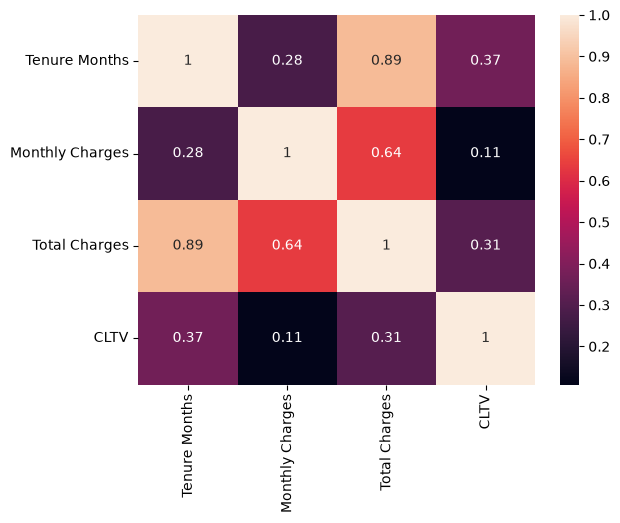

In [29]:
sns.heatmap(df_num.corr(method='spearman'), annot=True)
plt.show()

- Based on the plot above it shows that strong correlations are showed by tenure-totalcharges (0.89) and monthlycharges-totalcharges (0.64).

In [30]:
df_geo['Churn Label'] = df_cat['Churn Label']

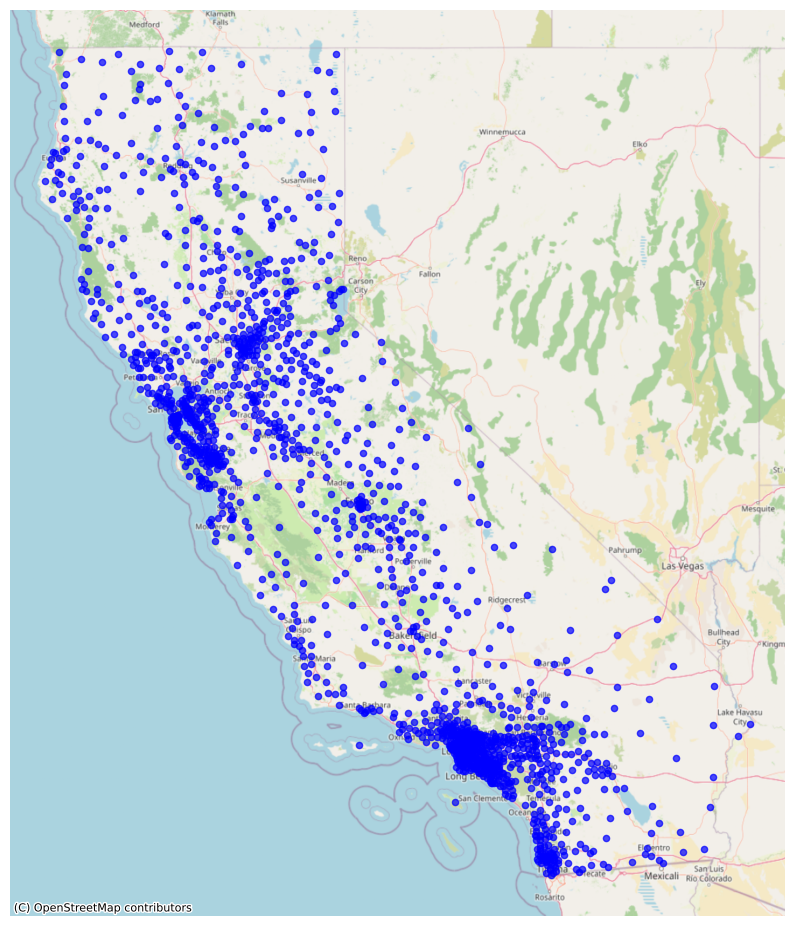

In [31]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point

# 1. Bersihkan data
df_map = df_geo.groupby(['Latitude', 'Longitude'])['CustomerID'].count().reset_index().dropna(subset=['Latitude', 'Longitude'])

# 2. Ubah data menjadi GeoDataFrame
geometry = [Point(xy) for xy in zip(df_map['Longitude'], df_map['Latitude'])]
gdf = gpd.GeoDataFrame(df_map, geometry=geometry, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(10, 15))

# 4. Plot titik biasa (tanpa hover, tanpa interaksi)
gdf.plot(ax=ax, color='blue', markersize=20, alpha=0.7)

# 5. Tambahkan peta biasa di latar belakang
ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.OpenStreetMap.Mapnik)

# 6. Hapus bingkai koordinat agar bersih seperti peta biasa
ax.set_axis_off()

plt.show()

# Feature Engineering

## Feature Encoding

In [32]:
df_cat = pd.get_dummies(df_cat, columns=['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Churn Label'], drop_first=True)

In [33]:
df_cat = pd.get_dummies(df_cat, columns=['Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Payment Method'])

## Train Test Split

In [34]:
df = df_num.copy()

In [35]:
df[df_cat.columns] = df_cat

In [36]:
X = df.drop(columns=['Churn Label_Yes'])
y = df['Churn Label_Yes']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

## Feature Scalling

In [38]:
scaler = RobustScaler()

In [39]:
scaler.fit(X_train[df_num.columns])

RobustScaler()

In [40]:
X_train[df_num.columns] = scaler.transform(X_train[df_num.columns])

In [41]:
X_test[df_num.columns] = scaler.transform(X_test[df_num.columns])

## Feature Importance

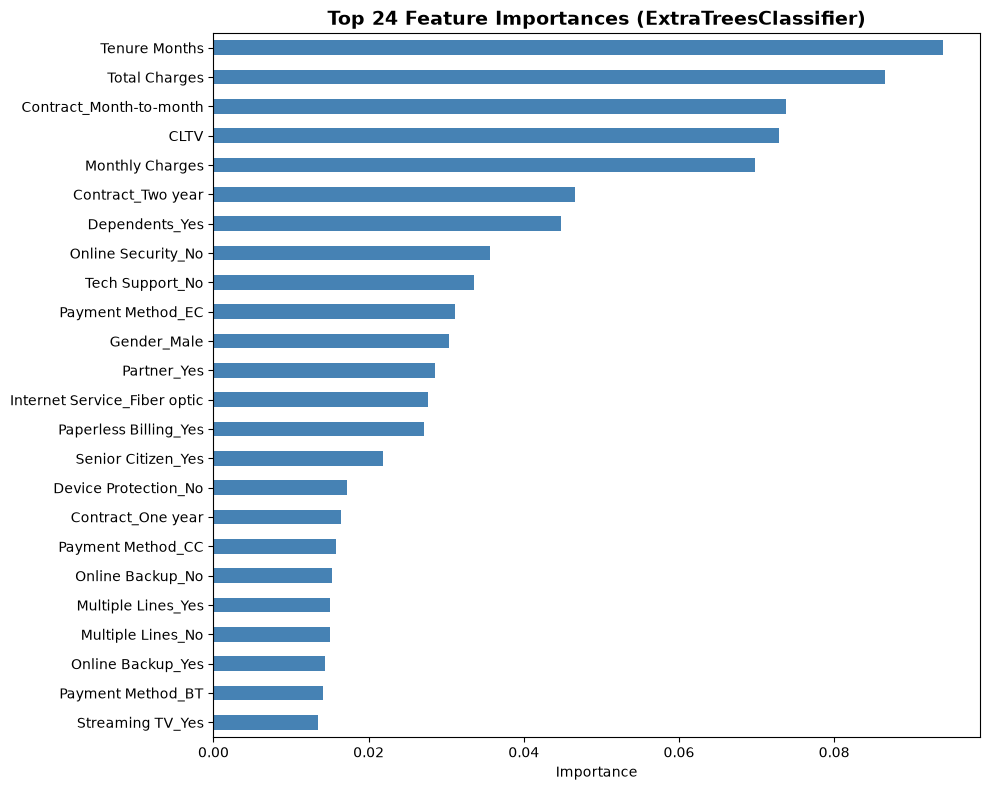

Selected 24 features contributing to 85% cumulative importance.
Top 10 selected features:
   1. Tenure Months
   2. Total Charges
   3. Contract_Month-to-month
   4. CLTV
   5. Monthly Charges
   6. Contract_Two year
   7. Dependents_Yes
   8. Online Security_No
   9. Tech Support_No
  10. Payment Method_EC


In [42]:
feature_importance = ExtraTreesClassifier(class_weight='balanced', bootstrap=True, oob_score=True, random_state=42, n_jobs=-1)
feature_importance.fit(X_train, y_train)

importances = pd.Series(feature_importance.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

cumulative_imp = importances.cumsum() / importances.sum()
n_selected = (cumulative_imp <= 0.85).sum() + 1   # +1 to include the feature that crosses 85%
n_selected = max(n_selected, 10)  # ensure at least 10 features

fig, ax = plt.subplots(figsize=(10, 8))
importances.head(n_selected).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title(f'Top {n_selected} Feature Importances (ExtraTreesClassifier)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

selected_features = importances.head(n_selected).index.tolist()
print(f'Selected {n_selected} features contributing to 85% cumulative importance.')
print(f'Top 10 selected features:')
for i, feat in enumerate(selected_features[:10], 1):
    print(f'  {i:>2}. {feat}')


In [43]:
X_train_sel = X_train[selected_features]

In [44]:
X_test_sel = X_test[selected_features]

# Modelling

## Random Forest

In [45]:
def bias_variance_analysis(model, X_train, y_train, cv=5, model_name="Model"):
    """
    Menghitung Bias dan Variance menggunakan K-Fold Cross-Validation
    
    Bias: Error pada training set (underfitting)
    Variance: Perbedaan error antar fold (overfitting)
    """
    kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    
    train_scores = []
    val_scores = []
    train_errors = []
    val_errors = []
    train_variances = []
    val_variances = []
    
    for train_idx, test_idx in kfold.split(X_train, y_train):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]
        
        # Train model
        model.fit(X_tr, y_tr)
        
        # Predictions
        y_train_pred = model.predict(X_tr)
        y_val_pred = model.predict(X_te)
        
        # Calculate errors
        score_train = accuracy_score(y_tr, y_train_pred)
        score_val = accuracy_score(y_te, y_val_pred)
        train_error = 1 - score_train
        val_error = 1 - score_val
        train_variance = y_train_pred.var()
        val_variance = y_val_pred.var()
        
        train_scores.append(score_train)
        val_scores.append(score_val)
        train_errors.append(train_error)
        val_errors.append(val_error)
        train_variances.append(train_variance)
        val_variances.append(val_variance)
        
    
    train_scores = np.array(train_scores) 
    val_scores = np.array(val_scores)
    train_errors = np.array(train_errors)
    val_errors = np.array(val_errors)
    train_variances = np.array(train_variances)
    val_variances = np.array(val_variances)
    
    # Calculate Bias and Variance
    
    
    return {
        'model':model,
        'train_scores': train_scores,
        'val_scores': val_scores,
        'train_bias': train_errors,
        'val_bias': val_errors,
        'train_variance': train_variances,
        'val_variance': val_variances,
        'avg_train_variance': train_variances.mean(),
        'avg_val_variance': val_variances.mean(),
        'avg_train_bias': train_errors.mean(),
        'avg_val_bias': val_errors.mean()
    }

In [46]:
def plot_bias_variance_from_analysis(result, figsize=(14,5), save_path=None, show=True):
    """
    Plot hasil bias-variance berdasarkan dict keluaran dari fungsi Anda.
    Memakai keys yang ada: 'avg_train_bias'/'avg_test_bias', 'train_variance', 'test_variance'.
    """
    train_var_arr = np.asarray(result.get('train_variance', []))
    val_var_arr  = np.asarray(result.get('val_variance',  []))
    train_bias_arr  = np.asarray(result.get('train_bias',  []))
    val_bias_arr  = np.asarray(result.get('val_bias',  []))
    avg_train_score = result.get('train_scores', np.nan).mean()
    avg_val_score = result.get('val_scores', np.nan).mean()
    avg_train_bias = result.get('avg_train_bias', np.nan)
    avg_val_bias = result.get('avg_val_bias', np.nan)
    avg_train_var = result.get('avg_train_variance', np.nan)
    avg_val_var = result.get('avg_val_variance', np.nan)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].plot(train_var_arr, label='Train Variance', marker='o')
    axes[0].plot(val_var_arr, label='Validation Variance', marker='o')
    axes[0].set_title('Variance Across Folds')
    axes[0].set_xlabel('Fold')
    axes[0].set_ylabel('Variance')  
    axes[0].legend(loc="upper right")
    axes[0].grid()

    axes[1].plot(train_bias_arr, label='Train Bias', marker='o')
    axes[1].plot(val_bias_arr, label='Validation Bias', marker='o')
    axes[1].set_title('Bias Across Folds')  
    axes[1].set_xlabel('Fold')
    axes[1].set_ylabel('Bias')
    axes[1].legend(loc="upper right")
    axes[1].grid()

    plt.show()

    print(f"Average Train Bias: {avg_train_bias:.4f}")
    print(f"Average Validation Bias: {avg_val_bias:.4f}")
    print(f"Average Train Variance: {avg_train_var:.4f}")
    print(f"Average Validation Variance: {avg_val_var:.4f}")
    print(f"Average Train Score: {avg_train_score:.4f}")
    print(f"Average Validation Score: {avg_val_score:.4f}")

In [47]:
from sklearn.metrics import confusion_matrix
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    


    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    auc_score_rf = roc_auc_score(y_test, y_pred)
    axes[1].plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc_score_rf:.2f})')
    axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")  # diagonal line
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('Receiver Operating Characteristic (ROC)')
    axes[1].legend(loc="lower right")
    axes[1].grid()
    plt.show()

    print("Classification Report:")
    print(classification_report(y_test, y_pred))

In [48]:
RF = RandomForestClassifier(
        class_weight='balanced', # handle weight for imbalanced data
        oob_score=True, # validation internal during training
        random_state=42 # for same results across runs
    )

In [49]:
rf_analysis = bias_variance_analysis(RF, X_train_sel, y_train, cv=5, model_name='Random Forest')

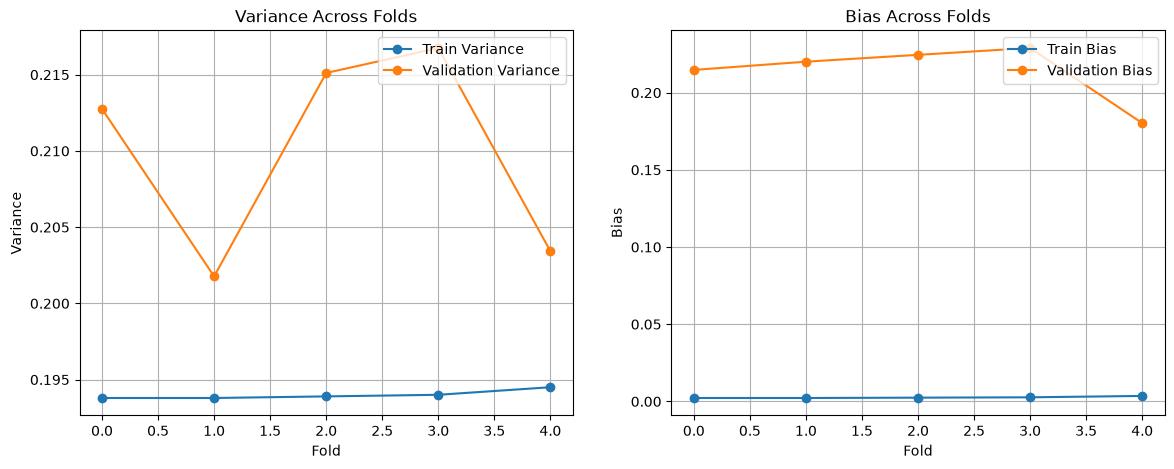

Average Train Bias: 0.0026
Average Validation Bias: 0.2137
Average Train Variance: 0.1940
Average Validation Variance: 0.2100
Average Train Score: 0.9974
Average Validation Score: 0.7863


In [50]:
plot_bias_variance_from_analysis(rf_analysis)

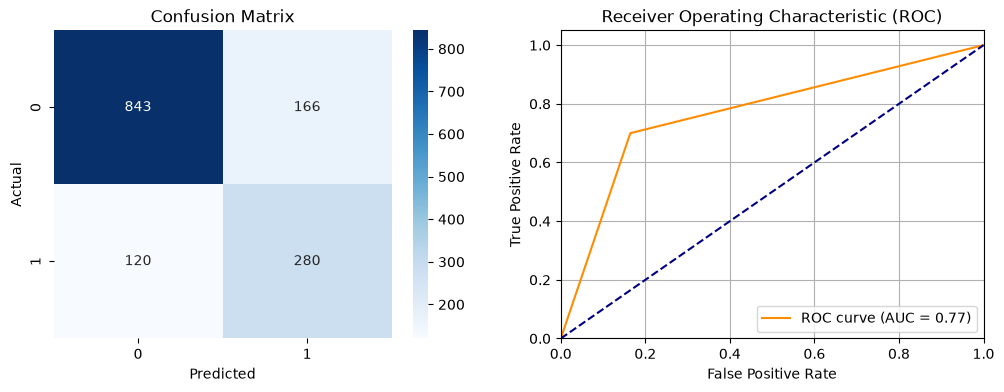

Classification Report:
              precision    recall  f1-score   support

       False       0.88      0.84      0.85      1009
        True       0.63      0.70      0.66       400

    accuracy                           0.80      1409
   macro avg       0.75      0.77      0.76      1409
weighted avg       0.81      0.80      0.80      1409



In [51]:
evaluate_model(rf_analysis['model'], X_test_sel, y_test)

## SVM

In [52]:
SVC = SVC(
        kernel='rbf', # kernel trick by making infinite dimensional space
        class_weight='balanced', # handle weight for imbalanced data
        gamma='auto', # kernel coefficient
        C=1.0, # value of l2 regularization
        probability=True,
        random_state=42 # for same results across runs
    )

In [53]:
svc_analysis = bias_variance_analysis(SVC, X_train_sel, y_train, cv=5, model_name='SVM')

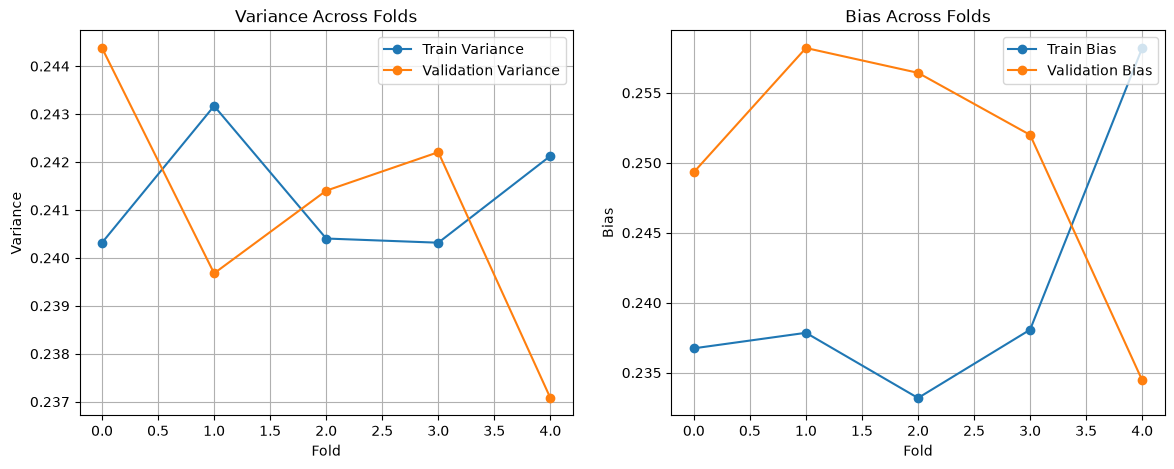

Average Train Bias: 0.2408
Average Validation Bias: 0.2501
Average Train Variance: 0.2413
Average Validation Variance: 0.2409
Average Train Score: 0.7592
Average Validation Score: 0.7499


In [54]:
plot_bias_variance_from_analysis(svc_analysis)

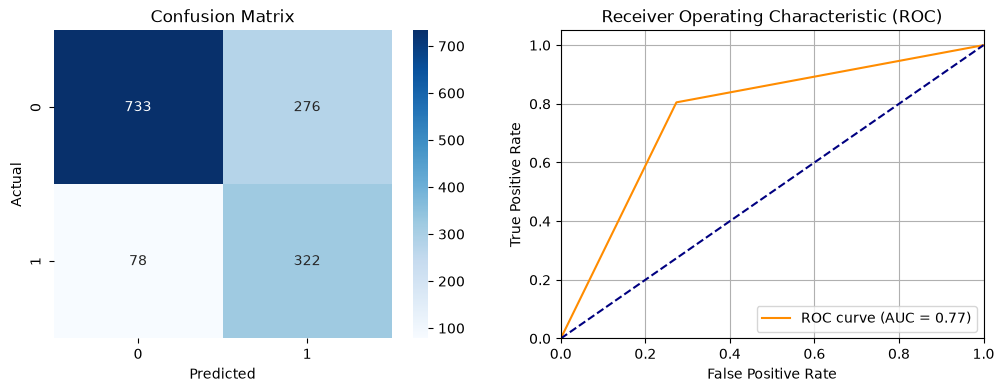

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.73      0.81      1009
        True       0.54      0.81      0.65       400

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.80      0.75      0.76      1409



In [55]:
evaluate_model(svc_analysis['model'], X_test_sel, y_test)

## SMOTETomek

In [56]:
st = SMOTETomek(random_state=42)
X_train_st, y_train_st = st.fit_resample(X_train_sel, y_train)

## RF + SMOTETomek

In [57]:
RF_ST = RandomForestClassifier(
        random_state=42, # for same results across runs
        class_weight='balanced', # handle weight for imbalanced data
        oob_score=True # validation internal during training
    )

In [58]:
RF_ST = RandomForestClassifier(
        random_state=42, # for same results across runs
        class_weight='balanced', # handle weight for imbalanced data
        oob_score=True # validation internal during training
    )

In [59]:
rf_st_analysis = bias_variance_analysis(RF_ST, X_train_st, y_train_st, cv=5, model_name='SVM')

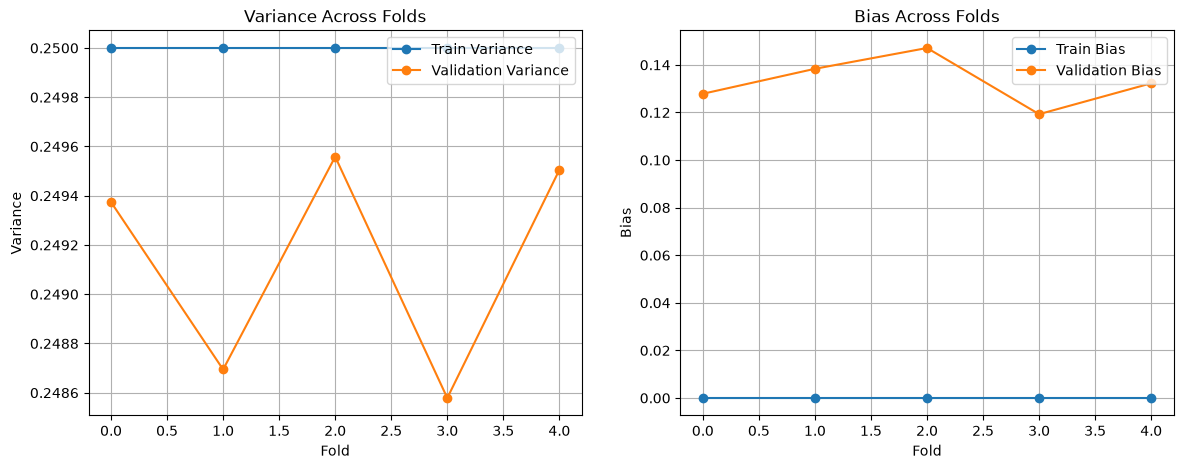

Average Train Bias: 0.0000
Average Validation Bias: 0.1330
Average Train Variance: 0.2500
Average Validation Variance: 0.2491
Average Train Score: 1.0000
Average Validation Score: 0.8670


In [60]:
plot_bias_variance_from_analysis(rf_st_analysis)

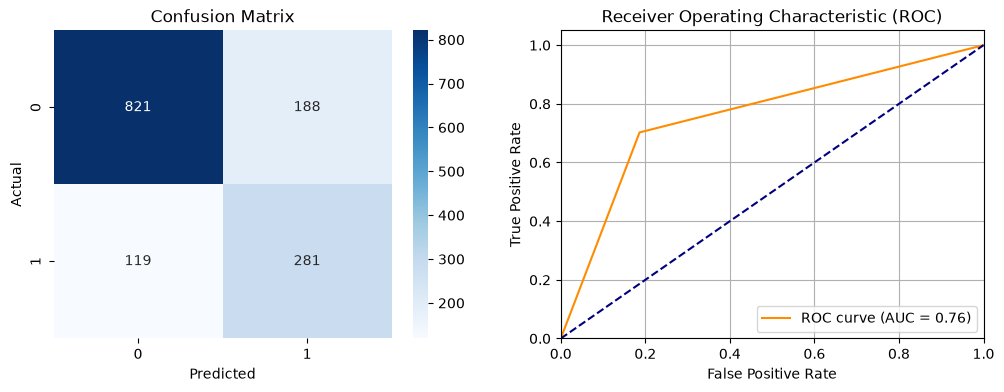

Classification Report:
              precision    recall  f1-score   support

       False       0.87      0.81      0.84      1009
        True       0.60      0.70      0.65       400

    accuracy                           0.78      1409
   macro avg       0.74      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [61]:
evaluate_model(rf_st_analysis['model'], X_test_sel, y_test)

## SVC + SMOTETomek

In [62]:
from sklearn.svm import SVC

In [63]:
SVC_ST = SVC(
        kernel='rbf', # kernel trick by making infinite dimensional space
        class_weight='balanced', # handle weight for imbalanced data
        gamma='auto', # kernel coefficient
        C=1.0, # value of l2 regularization
        probability=True,
        random_state=42 # for same results across runs
    )

In [64]:
svc_st_analysis = bias_variance_analysis(SVC_ST, X_train_st, y_train_st, cv=5, model_name='SVM')

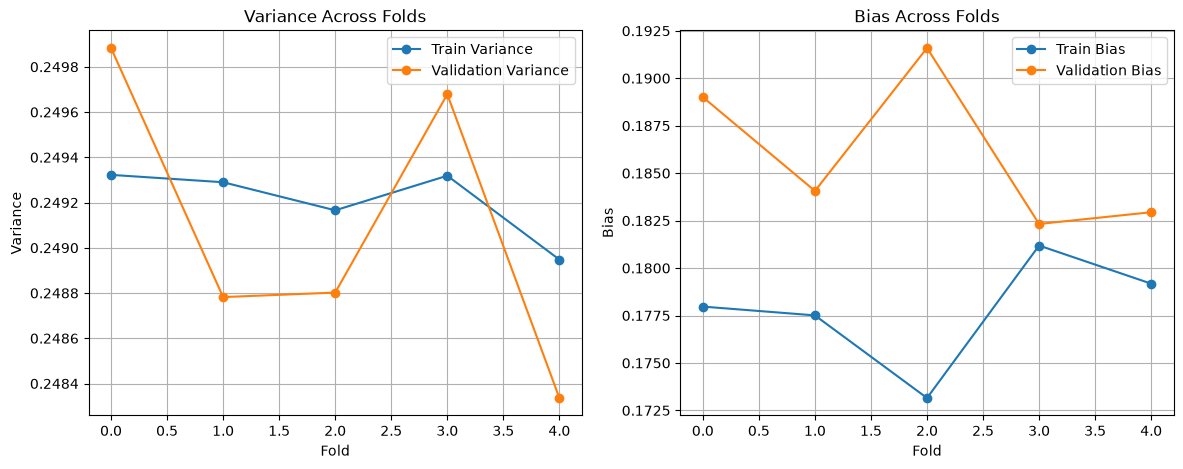

Average Train Bias: 0.1778
Average Validation Bias: 0.1860
Average Train Variance: 0.2492
Average Validation Variance: 0.2491
Average Train Score: 0.8222
Average Validation Score: 0.8140


In [65]:
plot_bias_variance_from_analysis(svc_st_analysis)

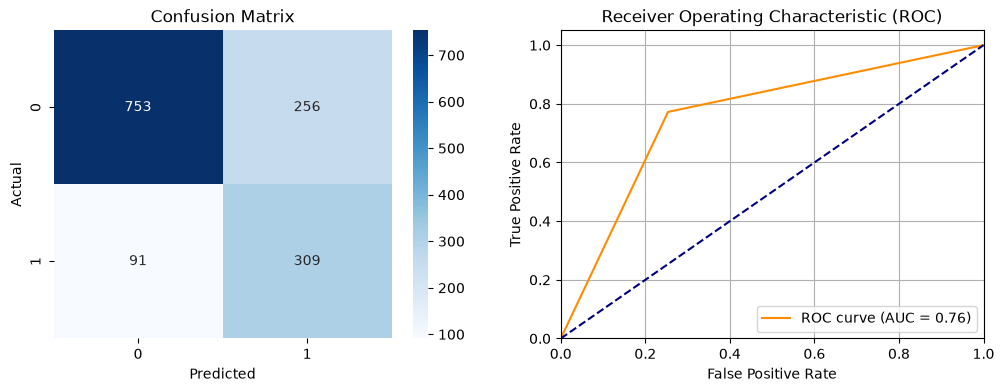

Classification Report:
              precision    recall  f1-score   support

       False       0.89      0.75      0.81      1009
        True       0.55      0.77      0.64       400

    accuracy                           0.75      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.79      0.75      0.76      1409



In [66]:
evaluate_model(svc_st_analysis['model'], X_test_sel, y_test)

## RF + Bayesian Tuning

In [67]:
param_grid_rf = {
    'n_estimators': [100, 200, 300], # number of trees in the forest
    'max_depth': [None, 10, 20], # maximum depth of the tree
    'min_samples_split': [2, 5, 8], # minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 5, 9] # minimum number of samples required to be at a leaf node
}

# Initialize Bayesian Optimization
rf_opt = BayesSearchCV(
    RandomForestClassifier(
        class_weight='balanced', # handle weight for imbalanced data
        oob_score=True, # validation internal during training
        random_state=42 # for same results across runs
    ),
    param_grid_rf,
    n_iter=40,
    scoring='recall',
    cv=5
)

In [68]:
rf_opt.fit(X_train_sel, y_train)

print(f"val. score: {rf_opt.best_score_}")

val. score: 0.7971721111652852


In [69]:
best_rf_params = rf_opt.best_params_
print("Best Hyperparameters:", best_rf_params)

Best Hyperparameters: OrderedDict({'max_depth': None, 'min_samples_leaf': 9, 'min_samples_split': 8, 'n_estimators': 100})


In [70]:
y_pred_rf_opt = rf_opt.predict(X_test_sel)

In [71]:
print("Best val score:", rf_opt.best_score_)

Best val score: 0.7971721111652852


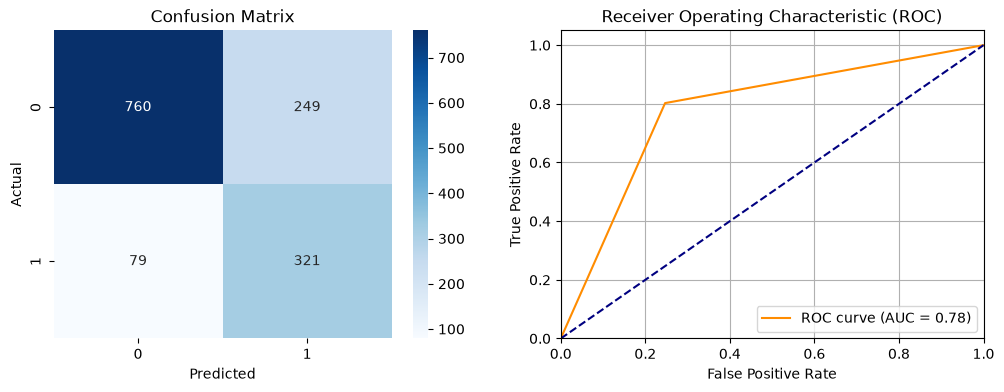

Classification Report:
              precision    recall  f1-score   support

       False       0.91      0.75      0.82      1009
        True       0.56      0.80      0.66       400

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.81      0.77      0.78      1409



In [72]:
evaluate_model(rf_opt, X_test_sel, y_test)

## SVC + Bayesian Tuning

In [73]:
param_grid_svc = {
    'C': [0.05, 1, 2, 5], # regularization l2 parameter
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1], # kernel coefficient 
    'kernel': ['rbf', 'linear', 'poly'] # kernel type to be used in the algorithm
}

# Initialize Bayesian Optimization
svc_opt = BayesSearchCV(
    SVC(
        class_weight='balanced', # handle weight for imbalanced data
        probability=True,
        random_state=42 # for same results across runs
    ),
    param_grid_svc,
    n_iter=30,
    scoring='recall',
    cv=5
)

In [74]:
svc_opt.fit(X_train_sel, y_train)


,estimator,SVC(class_wei...ndom_state=42)
,search_spaces,"{'C': [0.05, 1, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['rbf', 'linear', ...]}"
,n_iter,30
,scoring,'recall'
,cv,5
,optimizer_kwargs,None
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True


In [75]:
print("val. score:", svc_opt.best_score_)
print("Best Hyperparameters:", svc_opt.best_params_)


val. score: 0.8423254626082514
Best Hyperparameters: OrderedDict({'C': 0.05, 'gamma': 0.001, 'kernel': 'rbf'})


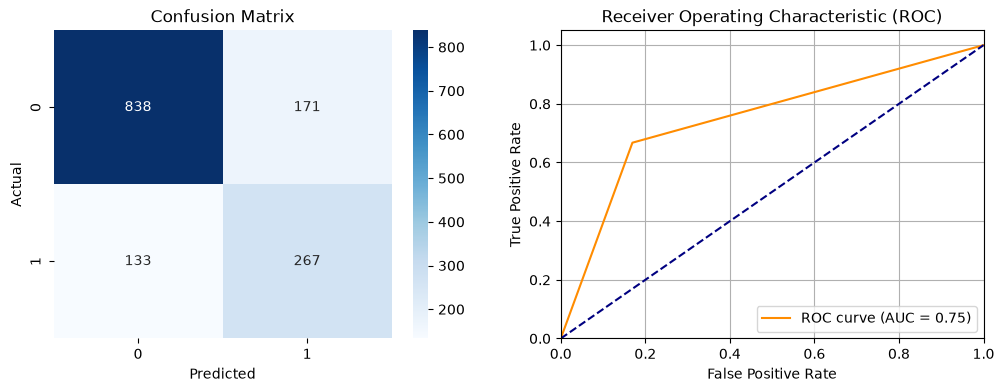

Classification Report:
              precision    recall  f1-score   support

       False       0.86      0.83      0.85      1009
        True       0.61      0.67      0.64       400

    accuracy                           0.78      1409
   macro avg       0.74      0.75      0.74      1409
weighted avg       0.79      0.78      0.79      1409



In [76]:
evaluate_model(svc_opt, X_test_sel, y_test)

## Recall

In [77]:
pd.DataFrame({
    'Ordinary' : [0.70, 0.81],
    'SMOTETomek' : [0.70, 0.77],
    'Bayesian Tuning': [0.80, 0.67],
}, index=['RF', 'SVC'])

,Ordinary,SMOTETomek,Bayesian Tuning
RF,0.70,0.70,0.80
SVC,0.81,0.77,0.67


## ROC AUC

In [78]:
pd.DataFrame({
    'Ordinary' : [0.77, 0.77],
    'SMOTETomek' : [0.76, 0.76],
    'Bayesian Tuning': [0.78, 0.75],
}, index=['RF', 'SVC'])

,Ordinary,SMOTETomek,Bayesian Tuning
RF,0.77,0.76,0.78
SVC,0.77,0.76,0.75


- Since the testing data is imbalanced, we prioritized Recall to reduce false negatives (cases where customers actually churn but are incorrectly predicted as non-churn) and ROC-AUC as a robust metric for imbalanced datasets.

- From the experiments conducted, the RF Bayesian Tuning model delivered the best performance, achieving Recall = 80% and ROC-AUC = 78%.

# Conclusion
This project explored Telco customer churn prediction by cleaning the raw dataset, performing EDA, handling imbalance, and evaluating multiple classification strategies.

Key EDA findings:
- The dataset is imbalanced: about 26.6% of customers churn while 73.4% stay.
- Numerical features show skewed distributions: churners are concentrated in lower tenure (2-29 months), higher monthly charges (56-94), and moderate total charges (134-2331).
- Categorical analysis revealed strong churn signals for month-to-month contracts, no online security, no tech support, fiber optic internet service, paperless billing, and electronic check payment.
- Correlation analysis showed a high relationship between tenure and total charges (0.89) and a moderate relationship between monthly charges and total charges (0.64), while churn-related associations were strongest with contract type and support/service features.

Modeling insights:
- Data preprocessing included encoding categorical variables, converting TotalCharges, and scaling skewed numeric features using RobustScaler.
- Imbalance handling with SMOTETomek and Bayesian hyperparameter tuning helped improve recall on the minority churn class.
- The best-performing model in this notebook was RF Bayesian Tuning, achieving recall = 80% and ROC AUC = 78% on the test set.

Overall, the project demonstrates that careful EDA, imbalance-aware evaluation, and hyperparameter tuning are essential for building a reliable churn prediction model. Future work can focus on richer feature engineering, ensemble models, and additional sampling or cost-sensitive learning techniques.